<a href="https://colab.research.google.com/github/tomz3302/Egyptian-Currency-Classifier/blob/main/Egyptian_Currency_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Egyptian Currency Classification Project
**Team Members:** Omar Dardir & Roger Sherif
**Dataset:** [Egyptian New Currency 2023](https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023)

### Environment Setup
Run this cell to install dependencies and import libraries.

In [32]:
!pip install opendatasets

import os
from scipy.stats import skew
from google.colab import drive
import opendatasets as od
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib # For saving the model later
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from PIL import Image
import shutil

# Define where your images are based on your screenshot
base_dir = './egyptian-new-currency-2023/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Common settings
IMG_SIZE = (224, 224) # Standard size for most models
BATCH_SIZE = 32

## Data Acquisition
In this section, we mount our shared Google Drive and download the currency images using the Kaggle API.

In [2]:

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project'

# This makes all your relative paths work from inside this folder
%cd {project_path}

# Verify where you are
!pwd

Mounted at /content/drive
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project


In [ ]:
dataset_folder = './egyptian-new-currency-2023'

if not os.path.exists(dataset_folder):
    print("Downloading dataset...")
    od.download("https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023")
else:
    print("Dataset already present in this session.")

Dataset already present in this session.


##Data Cleaning

In [ ]:
def tf_aggressive_clean(directory):
    print(f" Scanning {directory} with TensorFlow decoder...")
    removed_count = 0
    scanned_count = 0

    # Walk through all folders
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            scanned_count += 1

            # 1. Delete "Ghost" files (common Mac/Windows transfer artifacts)
            if file.startswith("._") or file == ".DS_Store":
                try:
                    os.remove(file_path)
                    removed_count += 1
                    print(f" Removed system file: {file}")
                except:
                    pass
                continue

            # 2. Ask TensorFlow to decode it
            try:
                # Read the raw bytes
                file_contents = tf.io.read_file(file_path)

                # Try to decode (this mimics what dataset_from_directory does)
                # expand_animations=False fixes issues with some BMP/GIFs disguised as JPGs
                img = tf.io.decode_image(file_contents, channels=3, expand_animations=False)

                # Force execution to catch corrupt data
                # (TensorFlow is lazy, so we must inspect the shape to trigger the decode)
                if img.shape is None or img.shape[0] == 0:
                    raise ValueError("Empty image")

            except Exception as e:
                # If TF failed, delete the file
                print(f" Deleting corrupt file: {file} | Error: {e}")
                try:
                    os.remove(file_path)
                    removed_count += 1
                except:
                    print(f"Could not delete {file_path}")

    print(f" Scan complete. Scanned {scanned_count} files. Removed {removed_count} bad files.")

# Update these paths to match your Colab folder structure exactly
base_dir = './egyptian-new-currency-2023/dataset'

tf_aggressive_clean(os.path.join(base_dir, 'train'))
tf_aggressive_clean(os.path.join(base_dir, 'valid'))
tf_aggressive_clean(os.path.join(base_dir, 'test'))

🔎 Scanning ./egyptian-new-currency-2023/dataset/train with TensorFlow decoder...
🗑️ Deleting corrupt file: 100.10.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 100.54.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.43.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.45.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting c

## Preprocessing
Before training, we need to:
1. Resize images to a uniform shape.
2. Normalize pixel values (0 to 1).
3. Split the data into Training and Validation sets.

In [33]:
# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)
class_names = train_ds.class_names
print(f"Captured classes: {class_names}")

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)
class_names = val_ds.class_names
print(f"Captured classes: {class_names}")

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)
class_names = test_ds.class_names

# Normalize the pixels
# Each pixel has a value from 0 to 255 (0 is black, 255 is white)
# This turns pixel values like 255 into 1.0, making it easier for the model to learn color patterns.

#X is the images, Y is the labels
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 2631 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 756 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 287 files belonging to 9 classes.


## Data Exploration
Just a quick look at a few sample images to make sure our labels (5, 10, 20 EGP, etc.) match the pictures.

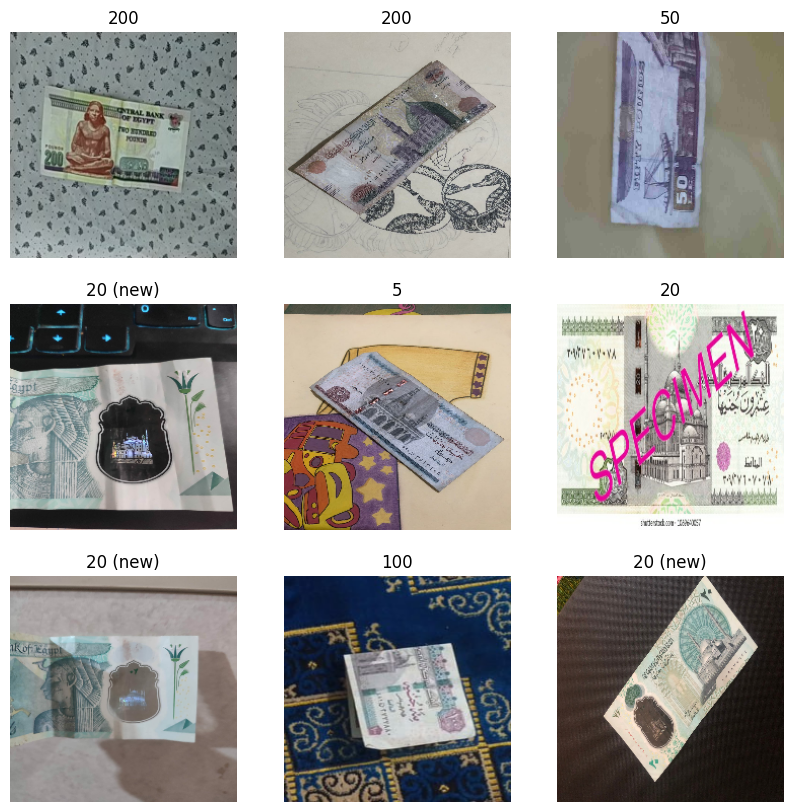

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        # We use the 'class_names' list we saved in the previous cell
        plt.title(class_names[labels[i]])
        plt.axis("off")

##Feature Extraction (HSV Histograms)

In [39]:
import cv2
import numpy as np
import tensorflow as tf
from scipy.stats import skew
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

def extract_combined_features(dataset):
    features = []
    labels = []

    print("Starting combined feature extraction...")

    # Iterate through the batches
    for images, batch_labels in dataset:
        for img, label in zip(images, batch_labels):

            # --- COMMON PREPROCESSING ---
            # Convert from [0, 1] float back to [0, 255] uint8 for OpenCV
            img_uint8 = (img.numpy() * 255).astype('uint8')

            # ==========================================
            # PART A: HSV FEATURES (Mask Based)
            # ==========================================
            img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)

            # Mask out background
            mask = cv2.inRange(img_hsv, (0, 40, 20), (180, 255, 255))
            masked_pixels = img_hsv[mask > 0]

            # HSV Moments (9 features)
            if len(masked_pixels) > 0:
                hsv_means = np.mean(masked_pixels, axis=0) # [H, S, V]
                hsv_stds = np.std(masked_pixels, axis=0)
                hsv_skews = skew(masked_pixels, axis=0)
            else:
                hsv_means = hsv_stds = hsv_skews = np.zeros(3)

            # HSV Histogram (512 features)
            hsv_hist = cv2.calcHist([img_hsv], [0, 1, 2], mask, [8, 8, 8], [0, 180, 0, 256, 0, 256])
            hsv_hist = cv2.normalize(hsv_hist, hsv_hist).flatten()

            # stack HSV parts
            features_hsv = np.hstack([hsv_hist, hsv_means, hsv_stds, hsv_skews])

            # ==========================================
            # PART B: RGB FEATURES (Crop Based)
            # ==========================================
            h, w, _ = img_uint8.shape
            margin_h = int(h * 0.1)
            margin_w = int(w * 0.1)
            center_crop = img_uint8[margin_h:h-margin_h, margin_w:w-margin_w]

            # RGB Histogram (512 features)
            rgb_hist = cv2.calcHist([center_crop], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
            rgb_hist = cv2.normalize(rgb_hist, rgb_hist).flatten()

            # RGB Moments (6 features)
            (R, G, B) = cv2.split(center_crop)
            rgb_means = [np.mean(R), np.mean(G), np.mean(B)]
            rgb_stds  = [np.std(R), np.std(G), np.std(B)]

            # stack RGB parts
            features_rgb = np.hstack([rgb_hist, rgb_means, rgb_stds])

            # ==========================================
            # PART C: COMBINE EVERYTHING
            # ==========================================
            # Total: 521 (HSV) + 518 (RGB) = 1039 Features
            combined_vector = np.hstack([features_hsv, features_rgb])

            features.append(combined_vector)
            labels.append(label.numpy())

    return np.array(features), np.array(labels)

# --- RUN EXTRACTION ---
# Note: Ensure your datasets (train_ds, etc.) are already defined as per your snippet
print("Extracting Train...")
X_train, y_train = extract_combined_features(train_ds)

print("Extracting Validation...")
X_val, y_val = extract_combined_features(val_ds)

print("Extracting Test...")
X_test, y_test = extract_combined_features(test_ds)

print(f"DONE. Final Train Shape: {X_train.shape}")
# Should be (N_samples, 1039)

Extracting Train...
Starting combined feature extraction...
Extracting Validation...
Starting combined feature extraction...
Extracting Test...
Starting combined feature extraction...
DONE. Final Train Shape: (2631, 1039)


## Model Training

In [49]:
model = XGBClassifier(
    n_estimators=3000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    tree_method='hist',
    random_state=42,
    reg_alpha=0.5,             # L1 regularization to fight noise
    reg_lambda=5,              # L2 regularization to fight noise
    early_stopping_rounds=20   # STOP if validation score doesn't improve for 20 rounds
)

print("Training with Early Stopping...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50  # Prints progress every 50 epochs/rounds
)

print(f"Stopped at epoch: {model.best_iteration}")

print("Model training finished!")

Training with Early Stopping...
[0]	validation_0-mlogloss:2.11759	validation_1-mlogloss:2.12837
[50]	validation_0-mlogloss:0.70174	validation_1-mlogloss:0.91288
[100]	validation_0-mlogloss:0.33547	validation_1-mlogloss:0.60424
[150]	validation_0-mlogloss:0.19036	validation_1-mlogloss:0.47434
[200]	validation_0-mlogloss:0.11946	validation_1-mlogloss:0.40378
[250]	validation_0-mlogloss:0.08215	validation_1-mlogloss:0.36460
[300]	validation_0-mlogloss:0.06089	validation_1-mlogloss:0.34019
[350]	validation_0-mlogloss:0.04796	validation_1-mlogloss:0.32428
[400]	validation_0-mlogloss:0.03958	validation_1-mlogloss:0.31348
[450]	validation_0-mlogloss:0.03394	validation_1-mlogloss:0.30559
[500]	validation_0-mlogloss:0.02988	validation_1-mlogloss:0.30045
[550]	validation_0-mlogloss:0.02688	validation_1-mlogloss:0.29652
[600]	validation_0-mlogloss:0.02453	validation_1-mlogloss:0.29247
[650]	validation_0-mlogloss:0.02269	validation_1-mlogloss:0.28979
[700]	validation_0-mlogloss:0.02118	validation_

Top 10 Most Important Features:
HSV_180    0.014328
RGB_98     0.011885
HSV_178    0.010022
RGB_55     0.009149
RGB_63     0.008493
HSV_203    0.007856
RGB_504    0.007305
HSV_127    0.007258
RGB_89     0.007070
HSV_219    0.006989
dtype: float32


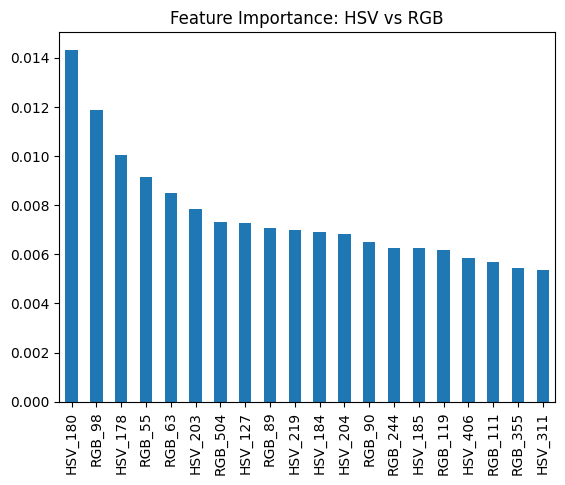

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get feature importance
importances = model.feature_importances_

# 2. Create a naming convention to track which feature came from where
# HSV has 521 features, RGB has 518. Total = 1039
hsv_labels = [f"HSV_{i}" for i in range(521)]
rgb_labels = [f"RGB_{i}" for i in range(518)]
all_labels = hsv_labels + rgb_labels

# 3. Plot top 20 features
feature_imp = pd.Series(importances, index=all_labels).sort_values(ascending=False)

print("Top 10 Most Important Features:")
print(feature_imp.head(10))

# Visual check: Are both HSV and RGB in the top 20?
feature_imp.head(20).plot(kind='bar')
plt.title("Feature Importance: HSV vs RGB")
plt.show()

# Evaluation
Testing the model on images it has never seen before to calculate the final accuracy.

Overall Accuracy: 91.01%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.95      0.97        20
          10       0.92      0.88      0.90        80
    10 (new)       0.93      0.92      0.93       130
         100       0.85      0.88      0.86        80
          20       0.91      0.94      0.93        80
    20 (new)       0.95      0.95      0.95       130
         200       0.96      0.91      0.94        79
           5       0.87      0.91      0.89        80
          50       0.83      0.84      0.84        77

    accuracy                           0.91       756
   macro avg       0.91      0.91      0.91       756
weighted avg       0.91      0.91      0.91       756



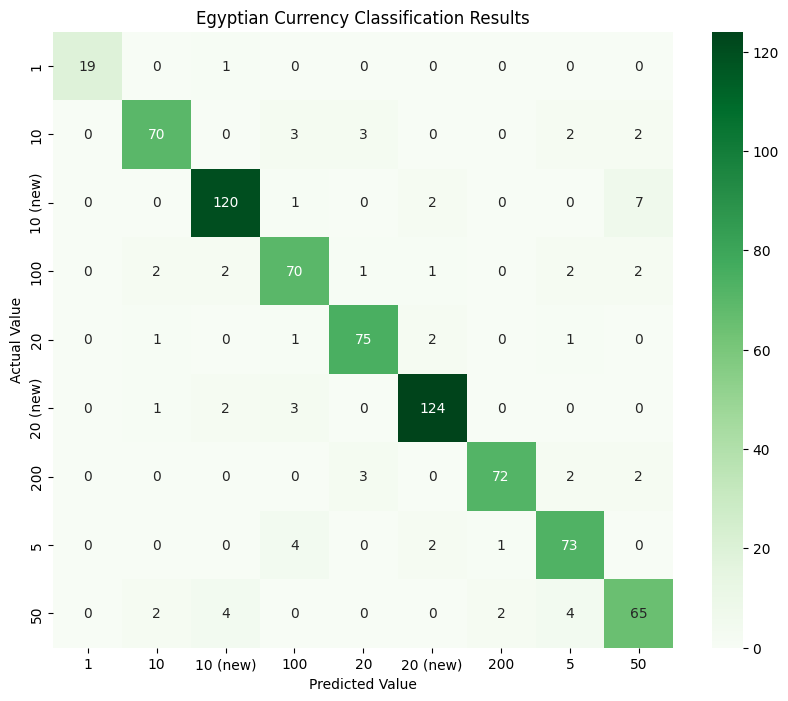

In [51]:
# Make predictions
y_pred = model.predict(X_val)

# Print Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# Detailed Report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# Visualize with a Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.title('Egyptian Currency Classification Results')
plt.show()

Training Accuracy: 99.96%
------------------------------
Training Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60
          10       1.00      1.00      1.00       315
    10 (new)       1.00      1.00      1.00       317
         100       1.00      1.00      1.00       313
          20       1.00      1.00      1.00       322
    20 (new)       1.00      1.00      1.00       346
         200       1.00      1.00      1.00       313
           5       1.00      1.00      1.00       334
          50       1.00      1.00      1.00       311

    accuracy                           1.00      2631
   macro avg       1.00      1.00      1.00      2631
weighted avg       1.00      1.00      1.00      2631



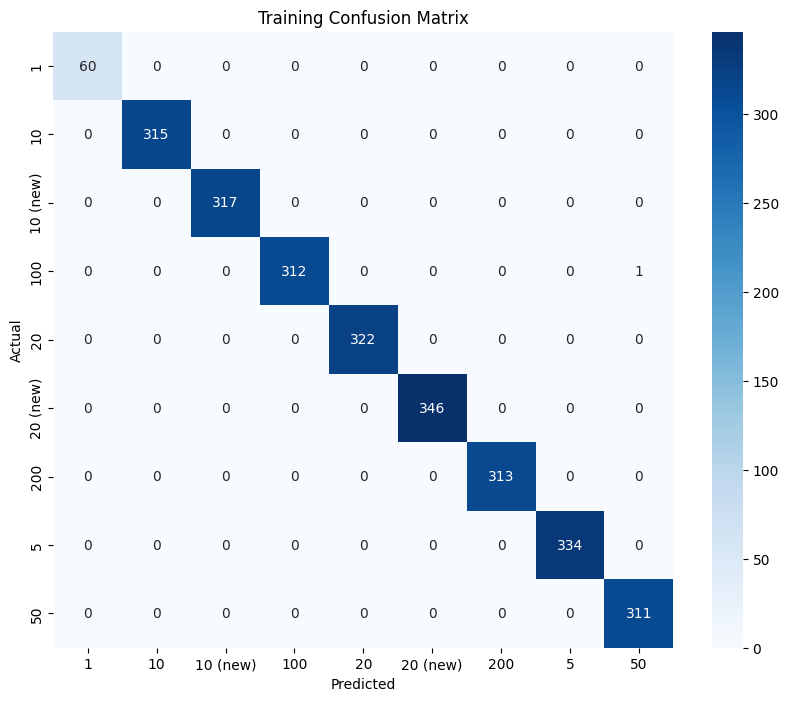

In [ ]:
# ===== Evaluate on Training Data =====
y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print("-" * 30)

print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=class_names))

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training Confusion Matrix')
plt.show()


Test Accuracy: 93.03%
------------------------------
Test Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
          10       0.92      0.94      0.93        35
    10 (new)       0.97      1.00      0.98        30
         100       0.87      0.97      0.92        35
          20       1.00      0.77      0.87        35
    20 (new)       0.94      1.00      0.97        30
         200       0.94      0.83      0.88        35
           5       0.88      1.00      0.93        35
          50       0.94      0.91      0.92        32

    accuracy                           0.93       287
   macro avg       0.94      0.94      0.93       287
weighted avg       0.93      0.93      0.93       287



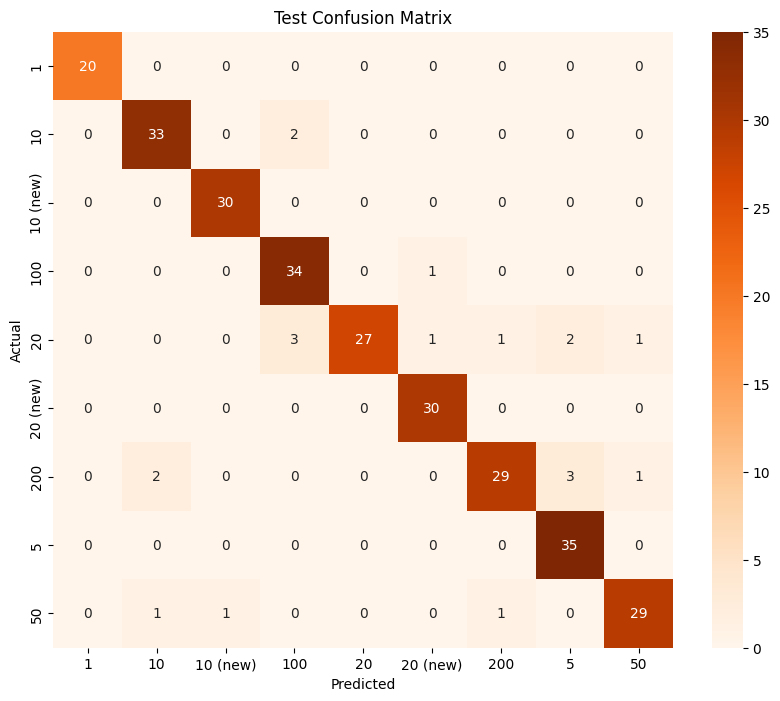

In [52]:
# ===== Evaluate on Test Data =====
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("-" * 30)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Oranges'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix')
plt.show()
